In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mplp
import matplotlib.lines as mpll

import shapely
import shapely.geometry as shgeo

import os
import io
import json
import getpass
import PIL
import requests
import pprint
import itertools

from panoptes_client import Subject

In [16]:
DATA_DIR = "/Users/hjd229/Documents/Data/Clump_Scout_2/beta_agg_test"
# CLASSIFICATIONS_FILE = "correct-a-clump-classifications.csv"
CLASSIFICATIONS_FILE = "galaxy-zoo-clump-scout-ii-classifications.csv"
TOOL_INDEX_LINESTYLES = {0: "-", 1: "--", 2: ":", 3: "-."}
TOOL_INDEX_LABELS = {0: "clump", 1: "fg star", 2: "bg galaxy", 3: "bulge"}
BOX_AREA_THRESHOLD = 1000 # pix**2

In [17]:
classifications = pd.read_csv(
    os.path.join(DATA_DIR, CLASSIFICATIONS_FILE),
    converters=dict(metadata=json.loads, annotations=json.loads),
)

In [18]:
beta_classifications = classifications.loc[
    classifications.created_at >= "2026-02-19 09:29:20 UTC"
]

In [19]:
per_subject_classifications = beta_classifications.groupby("subject_ids")

In [20]:
class BBox:

    def __init__(self, box_dict):
        for k, v in box_dict.items():
            setattr(self, k, v)

        self.attr_list = list(box_dict.keys())

        self.box = self.as_shapely()

        # A single box object can represent multiple identical boxes
        self.multiplicity = 1

    def iou(self, other):
        intersection = shapely.intersection(self.box, other.box).area
        union = shapely.union(self.box, other.box).area
        return intersection / union

    def max_iou(self, other):
        return max(other.iou(self), self.iou(other))

    def ioa(self, other):
        intersection = shapely.intersection(self.box, other.box).area
        return intersection / self.box.area

    def max_ioa(self, other):
        return max(other.ioa(self), self.ioa(other))

    def contains(self, other):
        return self.box.contains(other.box)

    def patch(self, **patch_kwargs):
        return mplp.Rectangle(
            [self.x_center - self.width / 2, self.y_center - self.height / 2],
            self.width,
            self.height,
            **patch_kwargs,
        )

    def as_dict(self):
        return {attr: getattr(self, attr) for attr in self.attr_list}

    def as_series(self):
        return pd.Series(self.as_dict())

    def as_shapely(self):
        return shgeo.box(
            self.x_center - self.width / 2,
            self.y_center - self.height / 2,
            self.x_center + self.width / 2,
            self.y_center + self.height / 2,
        )

    @classmethod
    def from_shapely(cls, shapely_box, **attr_kwargs):
        x_min, y_min, x_max, y_max = shapely_box.bounds
        return cls(
            dict(
                x_center=0.5 * (x_max + x_min),
                y_center=0.5 * (y_max + y_min),
                width=x_max - x_min,
                height=y_max - y_min,
            )
            | attr_kwargs
        )

    @classmethod
    def from_shapely_like(cls, shapely_box, box):
        x_min, y_min, x_max, y_max = shapely_box.bounds
        return cls(
            dict(
                x_center=0.5 * (x_max + x_min),
                y_center=0.5 * (y_max + y_min),
                width=x_max - x_min,
                height=y_max - y_min,
            )
            | box.as_dict()
        )

    @classmethod
    def from_df(cls, df):
        return [cls(dict(row)) for _, row in df.iterrows()]

    @classmethod
    def mean(cls, boxes, use_majority_label=True):
        bounds = np.array([box.box.bounds for box in boxes])
        multiplicities = [box.multiplicity for box in boxes]
        mean_bounds = np.average(bounds, weights=multiplicities, axis=0)
        if use_majority_label:
            majority_label = cls.majority_label(boxes)
            return cls.from_shapely(
                shgeo.box(*mean_bounds),
                **(boxes[0].as_dict() | dict(toolIndex=majority_label)),
            )
        return cls.from_shapely_like(shgeo.box(*mean_bounds), boxes[0])

    @classmethod
    def median(cls, boxes, use_majority_label=True):
        bounds = np.concatenate([[box.box.bounds]*box.multiplicity for box in boxes])
        median_bounds = np.median(bounds, axis=0)
        if use_majority_label:
            majority_label = cls.majority_label(boxes)
            return cls.from_shapely(
                shgeo.box(*median_bounds),
                **(boxes[0].as_dict() | dict(toolIndex=majority_label)),
            )
        return cls.from_shapely_like(shgeo.box(*median_bounds), boxes[0])

    @staticmethod
    def majority_label(boxes):
        labels = [[b.toolIndex]*b.multiplicity for b in boxes]
        label_counts = np.unique_counts(labels)
        label = label_counts.values[label_counts.counts.argmax()]
        return int(label)

    def __str__(self):
        attrs = json.dumps(self.as_dict(), indent=4)
        return f"BBox:\n{attrs}"

    def __repr__(self):
        return self.__str__()
    
    def __hash__(self) -> int:
        return hash(self.box.bounds)
    
    def __eq__(self, value: object) -> bool:
        return hash(self) == hash(value)
    
    def __lt__(self, value: object) -> bool:
        return hash(self) < hash(value)

In [21]:
def get_subject_image(url):
    return np.array(PIL.Image.open(io.BytesIO(requests.get(url).content)))


def plot_subject(locations):
    fig, panels = plt.subplots(figsize=(14, 21), nrows=3, ncols=2)
    for image_dict, panel_row in zip(locations, panels):
        for v in image_dict.values():
            image_data = get_subject_image(v)
            kwargs = dict(cmap="Greys") if image_data.ndim == 2 else dict()
            panel_row[0].imshow(image_data, **kwargs)
            panel_row[1].imshow(image_data, **kwargs)

    return fig, panels


def make_boxes(annotations, classification_id, subject_id):
    boxes = list(filter(lambda b: b.box.area < BOX_AREA_THRESHOLD, [
        BBox(
            box_dict
            | dict(
                classification_id=classification_id,
                box_id=box_id,
                subject_id=subject_id,
            )
        )
        for box_id, box_dict in enumerate(annotations[0]["value"])
    ]))
    return boxes


def plot_boxes(boxes, ax, **patch_kwargs):
    for box in boxes:
        ax.add_patch(
            box.patch(**(dict(ls=TOOL_INDEX_LINESTYLES[box.toolIndex]) | patch_kwargs))
        )


def plot_annotations(annotations, classification_id, subject_id, ax, **patch_kwargs):
    assert len(annotations) == 1
    boxes = make_boxes(annotations, classification_id, subject_id)
    plot_boxes(boxes, ax, **patch_kwargs)

    return boxes


def make_legend(ax):
    lines = [
        mpll.Line2D([0], [0], color="k", lw=2, ls=ls)
        for ls in TOOL_INDEX_LINESTYLES.values()
    ]
    labels = [label.title() for label in TOOL_INDEX_LABELS.values()]
    ax.legend(lines, labels, ncols=len(labels))


def get_overlapping_clusters(boxes, iou_threshold=0.5, ioa_threshold=0.5):
    ious, ioas, contains = np.fromiter(
        itertools.starmap(
            lambda b1, b2: [b1.max_iou(b2), b1.max_ioa(b2), float(b1.contains(b2))], itertools.product(boxes, boxes)
        ),
        dtype=np.dtype((float,3)),
    ).reshape((len(boxes), -1, 3)).T

    contains = contains > 0.5

    df_index = pd.MultiIndex.from_tuples(
        [(b.classification_id, b.box_id) for b in boxes]
    )
    ious_frame = pd.DataFrame(ious, index=df_index, columns=df_index)
    box_frame = pd.DataFrame([b.as_series() for b in boxes]).set_index(
        ["classification_id", "box_id"]
    )
    overlap_indices = (
        (ious_frame > iou_threshold) | contains | (ioas > ioa_threshold)
    ).apply(lambda x: x.loc[x].index)

    overlap_clusters = [
        box_frame.loc[overlap_indices_subset]
        for _, overlap_indices_subset in overlap_indices.items()
    ]
    return overlap_clusters

0 110778142
1 110778143
2 110778144
3 110778145
4 110778146
5 110778147
6 110778148


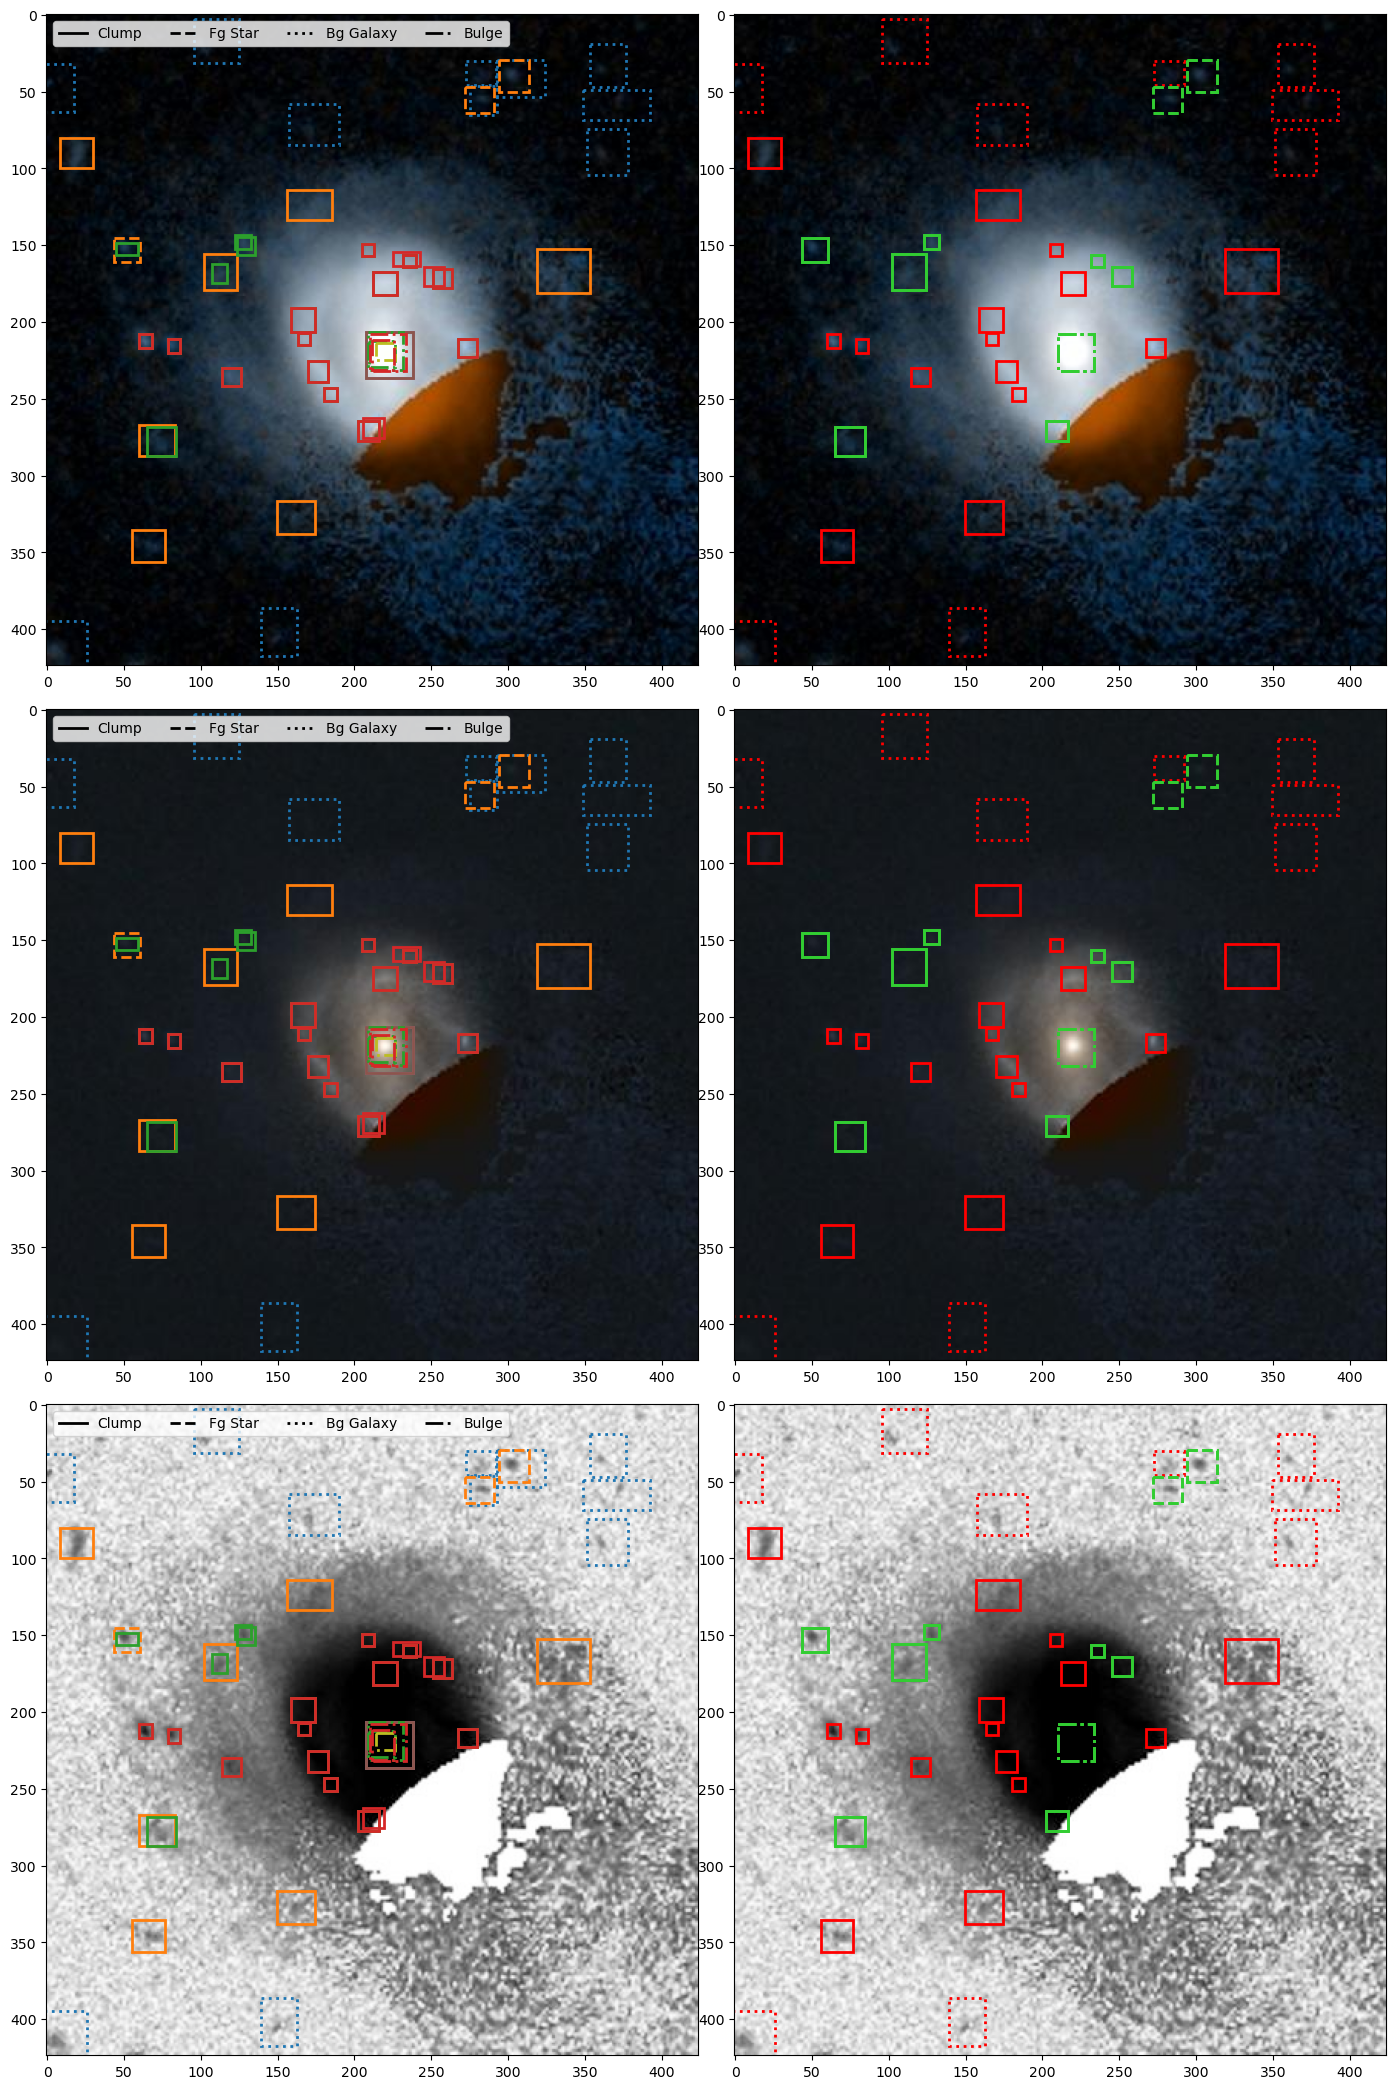

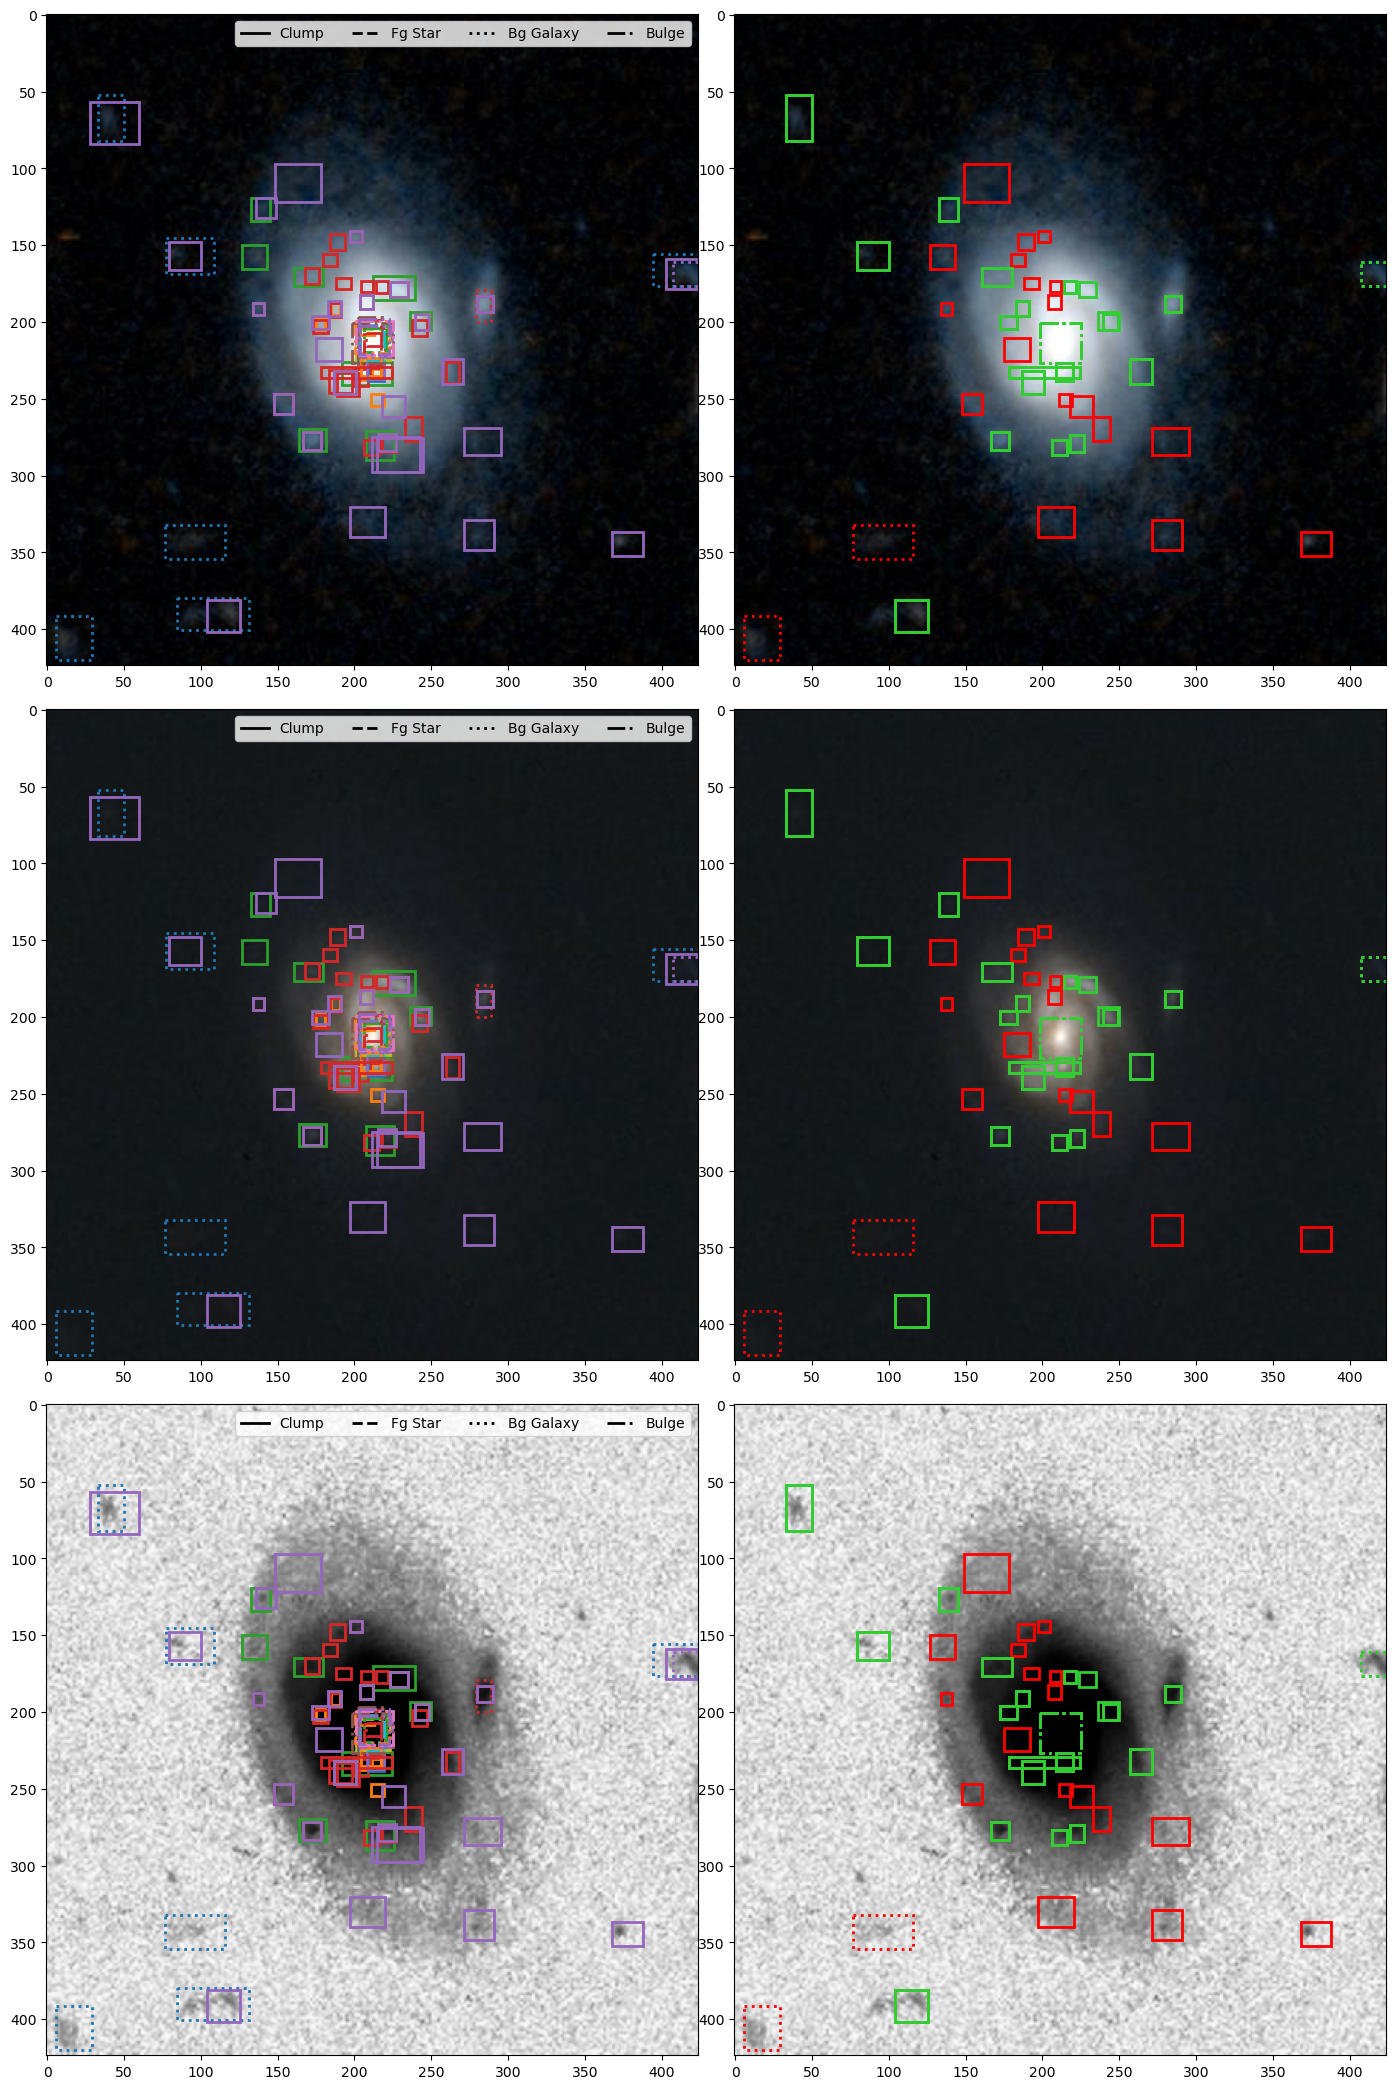

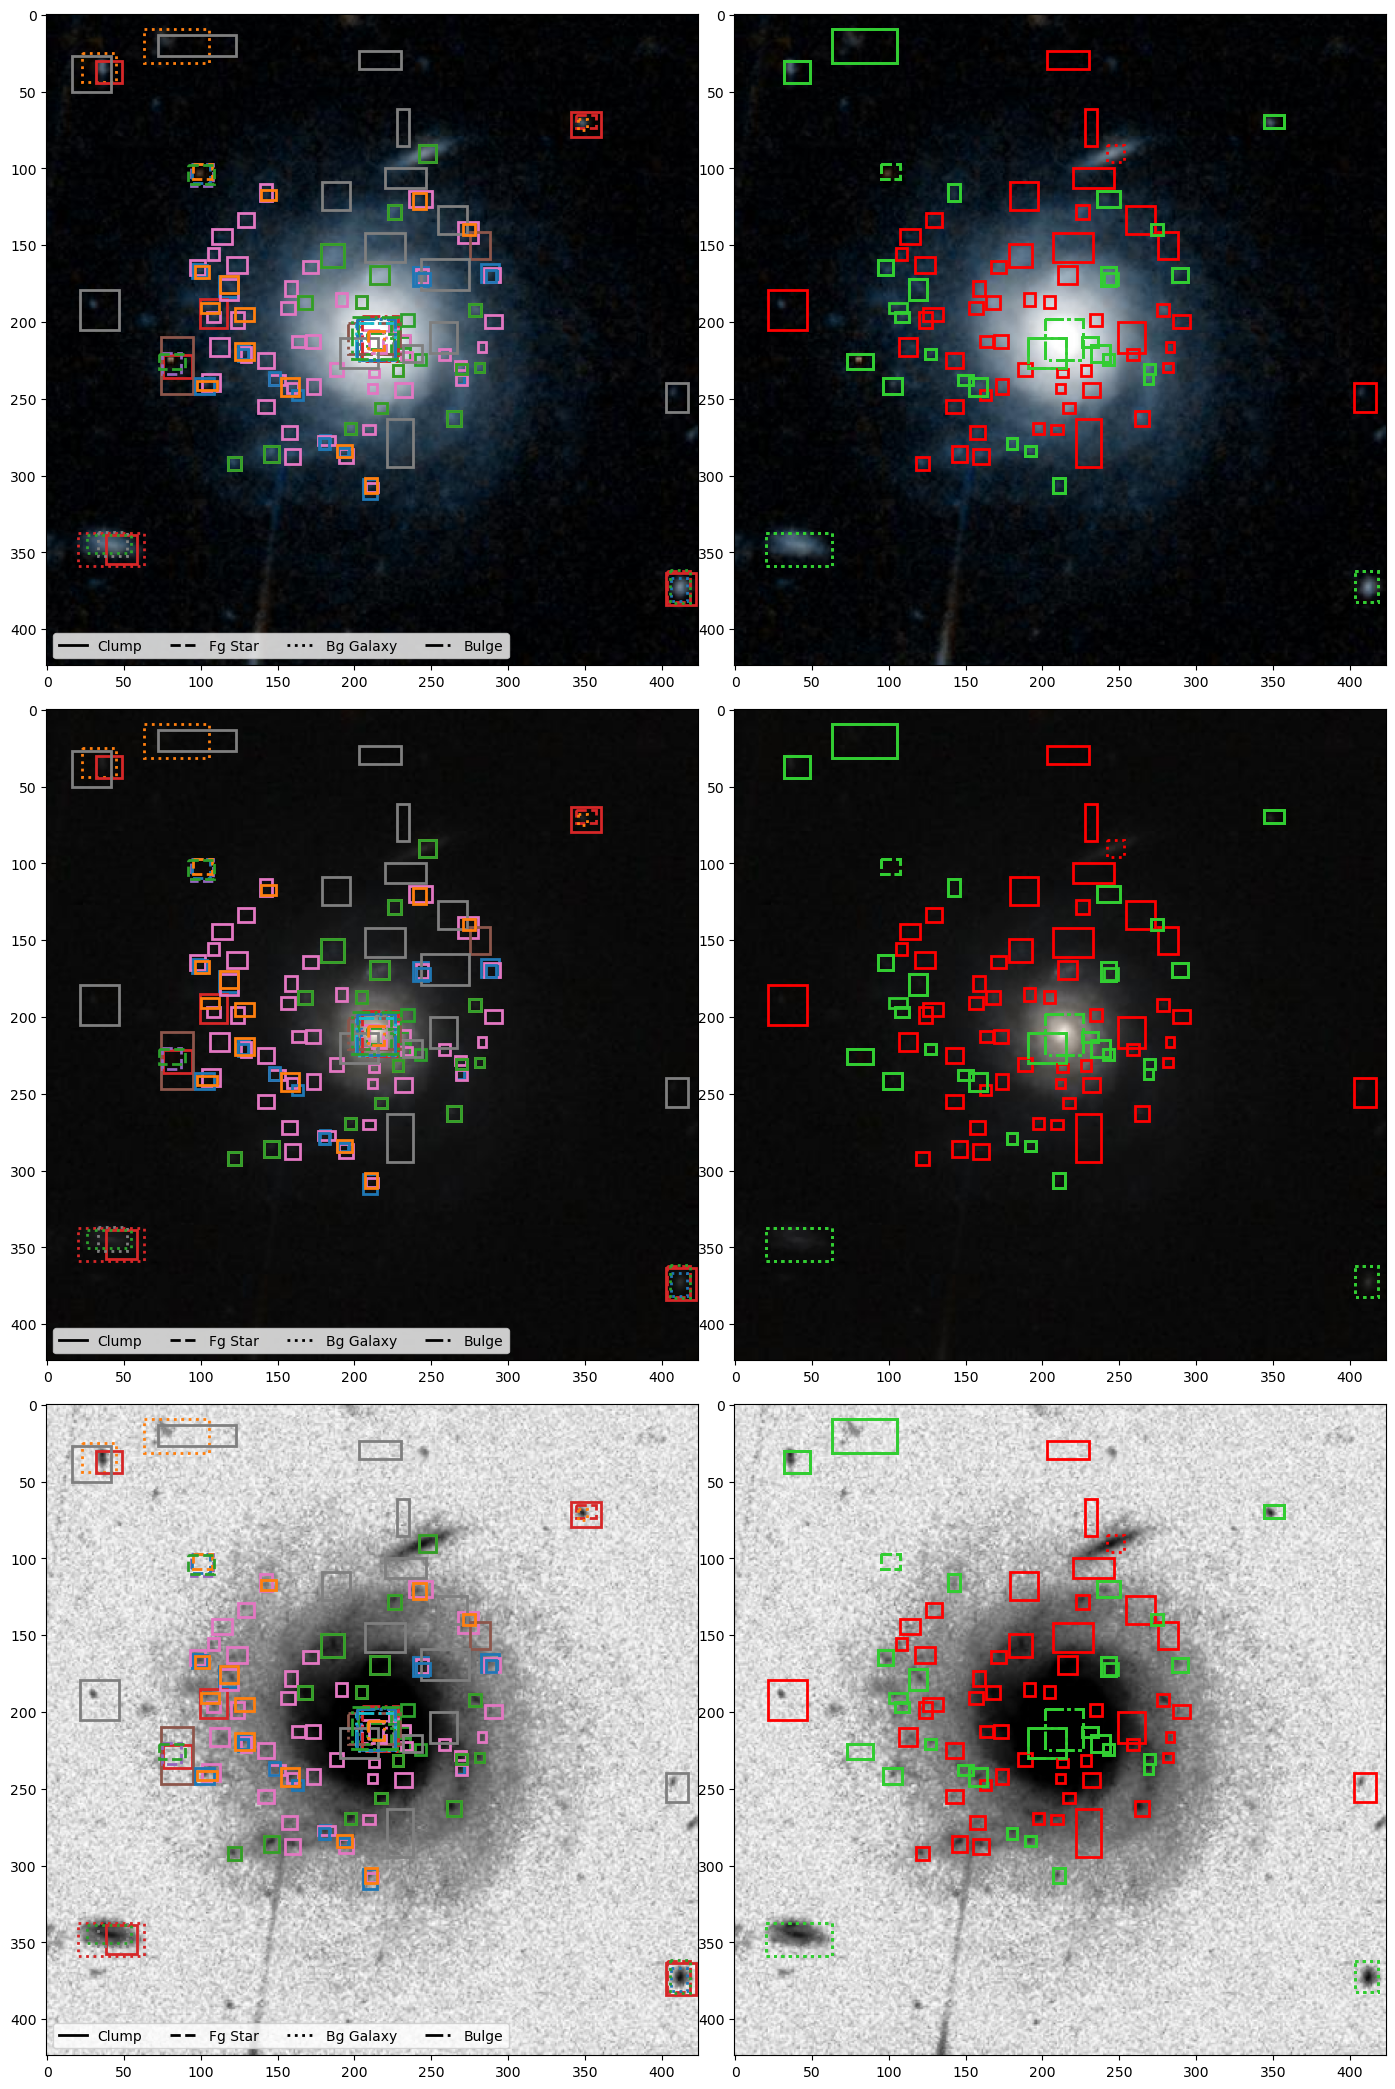

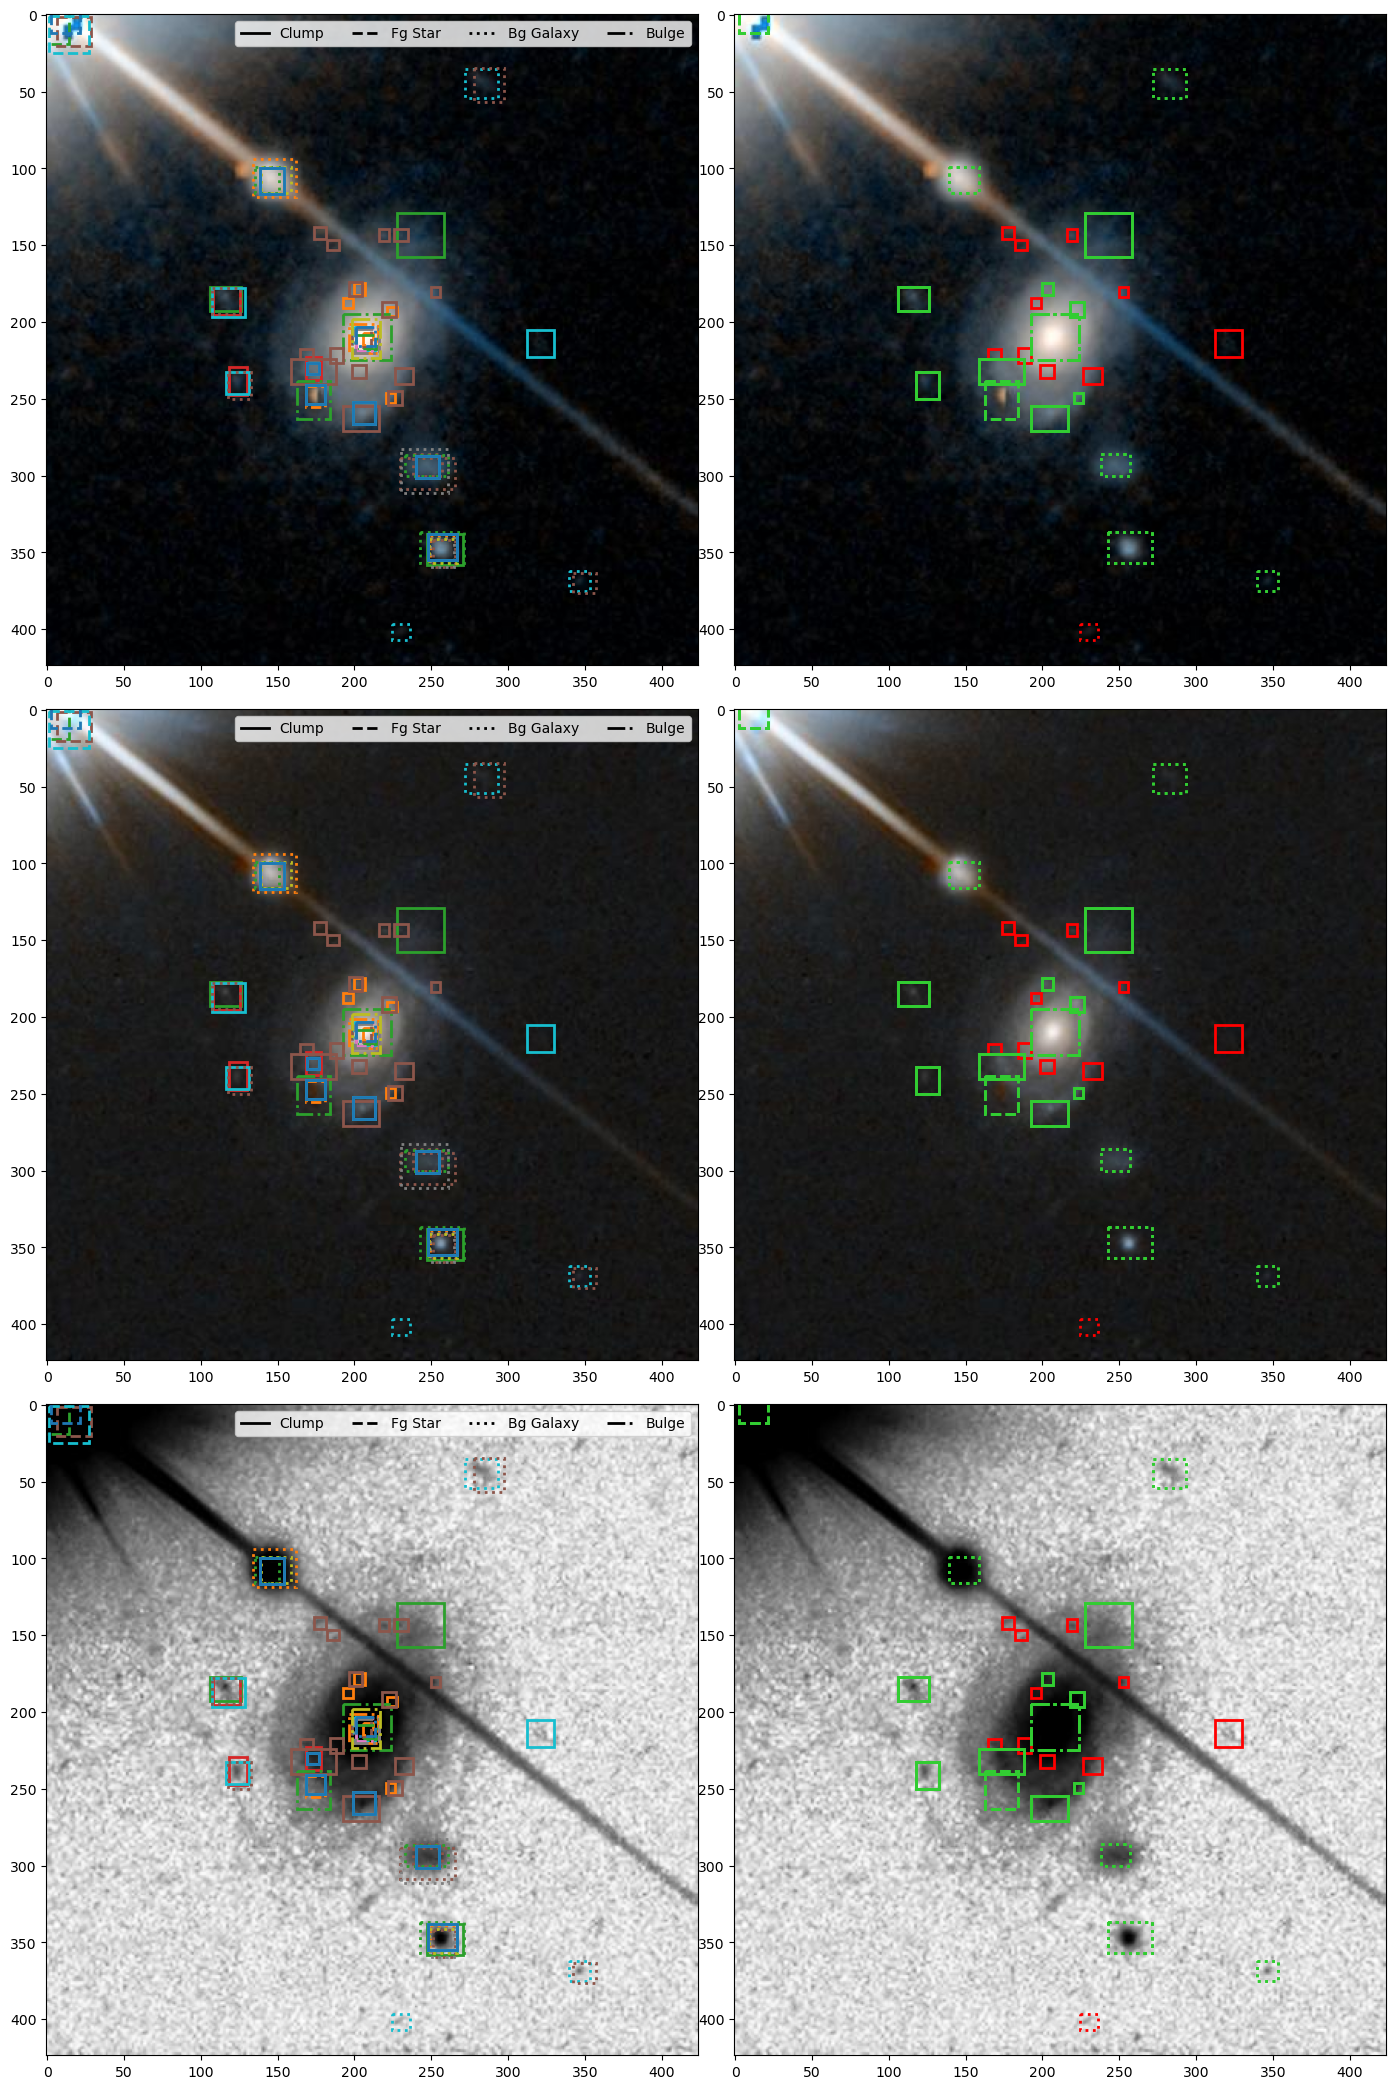

In [25]:
for i_subject, (subject_id, subject_data) in enumerate(per_subject_classifications):

    # if not i_subject % 10:
    print(i_subject, subject_id)

    all_boxes = []

    make_plots = i_subject < 4

    subject = Subject.find(subject_id)
    if make_plots:
        fig, panels = plot_subject(subject.locations)
        for i_c, (classification_id, annotations) in enumerate(
            subject_data.annotations.items()
        ):
            for panel in panels[:, 0]:
                boxes = plot_annotations(
                    annotations,
                    classification_id,
                    subject_id,
                    panel,
                    ec=f"C{i_c}",
                    fc="none",
                    lw=2,
                )
                make_legend(panel)
            all_boxes.extend(boxes)
    else:
        for i_c, (classification_id, annotations) in enumerate(
            subject_data.annotations.items()
        ):
            all_boxes.extend(make_boxes(annotations, classification_id, subject_id))

    unique_boxes, unique_box_counts = np.unique(all_boxes, return_counts=True)

    for b, c in zip(unique_boxes, unique_box_counts):
        b.multiplicity = c

    overlapping_clusters_raw = get_overlapping_clusters(unique_boxes)

    overlapping_clusters = [
        BBox.from_df(overlapping_cluster.reset_index())
        for overlapping_cluster in overlapping_clusters_raw
    ]

    mean_aggregated = []
    median_aggregated = []

    for overlapping_cluster in overlapping_clusters:
        mean_aggregated.append(BBox.mean(overlapping_cluster, use_majority_label=True))
        median_aggregated.append(
            BBox.median(overlapping_cluster, use_majority_label=True)
        )
        if make_plots:
            for panel in panels[:, 1]:
                if len(overlapping_cluster) == 1:
                    plot_boxes(
                        mean_aggregated[-1:],
                        ax=panel,
                        ec="r",
                        fc="none",
                        lw=2,
                    )
                else:
                    plot_boxes(
                        mean_aggregated[-1:],
                        ax=panel,
                        ec="limegreen",
                        fc="none",
                        lw=2,
                    )
    if make_plots:
        plt.tight_layout()

    if i_subject > 5:
        break

In [ ]:
mean_aggregated_frame = pd.DataFrame(
    [box.as_series() for box in mean_aggregated]
).set_index(["subject_id", "classification_id", "box_id"])

In [ ]:
median_aggregated_frame = pd.DataFrame(
    [box.as_series() for box in median_aggregated]
).set_index(["subject_id", "classification_id", "box_id"])